In [1]:
import sys
import os
from datetime import datetime
from collections import OrderedDict

import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt
from matplotlib import colormaps

from tqdm import tqdm


import wandb

from torchvision.models import VGG


import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets.folder import default_loader

from zennit.attribution import Gradient

from xaikd.utils import metrics
from xaikd import models, datasets, utils
from xaikd import attributors
from xaikd import explainers

from sklearn.metrics import ConfusionMatrixDisplay

/home/pat/projects/xai-kd/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
WANDB_API = wandb.Api()

In [3]:
# os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
NOTEBOOK_NAME = "figure1"
WANDB_PROJECT = "xaikd-s41-why-heatmaps-are-bad"

GROUP = "reproducing-v3"
TOTAL_SEEDS = 3

# Data Reader

In [5]:
def read_data(
    teacher, student,
    dataset,
    dataset_variant,
    policy,
    training_size=1.0,
    verbose=False,
):
    
    
    additional_query = {}

    if dataset_variant == "spurious-threespurious--1.0":
        if policy != "ce_only":
            additional_query = {"config.default-lambda-layer-config": "imagenet-spurious"}
    
    

    if policy == "ce_only":
        policy = "nothing"
        lambda_task = 1.0
        lambda_kd = 0.0
    else:
        lambda_task = 0.0
        lambda_kd = 1.0
    
    if policy == "kd_only":
        policy = "nothing"
    

    
    
    runs = WANDB_API.runs(
        WANDB_PROJECT,
        {
        "$and": [
            {"group": {"$in": [GROUP]}},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.dataset": dataset},
            {"config.dataset-variant": dataset_variant},
            {"config.training_size": training_size},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": policy},
            additional_query
        ]
        }
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    for run in runs:
        seed = run.config["seed"]
        if not "arr_metrics"in run.summary:
            print(f">> bad run config (id={run.id}")

            count += 1
            return run
            continue

        
        best_val_acc = run.summary["arr_metrics"]["val_acc"][-1]
    
        best_train_acc = run.summary["arr_metrics"]["train_acc"][-1]


        rows.append(
            dict(
                val_acc=best_val_acc, 
                train_acc=best_train_acc,
                teacher_acc=run.summary["teacher_acc"],
                run_id=run.id,
                **run.config
            )
        )

    if count != 0:
        print(f"We have {count} bad run! abort!")
        raise
    
    df = pd.DataFrame(rows)
    np.testing.assert_allclose(
        df.shape[0],
        TOTAL_SEEDS
    )

    df = df.sort_values(by="val_acc", ascending=False)

    
    return df
  
_df = read_data(
    teacher="imagenet-resnet18-tv",
    student="student-32-24-16-8",
    policy="basis-identity:prca-sortabs--uncentered",
#     policy="vid",
    
    dataset="imagenet-butterfly",
    dataset_variant="spurious-threespurious--1.0",
    training_size=1.0,

    verbose=True,
)
_df

we have 3 runs


,val_acc,train_acc,teacher_acc,run_id,lr,seed,epochs,layers,policy,dataset,...,training_size,dataset-variant,last_layer_policy,enable_checkpointing,wandb-experiment-group,wandb_experiment_group,parameter_partition_mode,finetuning_with_layer_loss,default-lambda-layer-config,default_lambda_layer_config
1,0.830000,0.889721,0.923333,m9f21ll1,0.0005,2,100,"layer3:layer3,layer4:layer4",basis-identity:prca-sortabs--uncentered,imagenet-butterfly,...,1,spurious-threespurious--1.0,kd,True,reproducing-v3,reproducing-v3,@0,True,imagenet-spurious,imagenet-spurious
2,0.800000,0.889463,0.923333,mur2w1m6,0.0005,1,100,"layer3:layer3,layer4:layer4",basis-identity:prca-sortabs--uncentered,imagenet-butterfly,...,1,spurious-threespurious--1.0,kd,True,reproducing-v3,reproducing-v3,@0,True,imagenet-spurious,imagenet-spurious
0,0.793333,0.895919,0.923333,64f92su8,0.0005,3,100,"layer3:layer3,layer4:layer4",basis-identity:prca-sortabs--uncentered,imagenet-butterfly,...,1,spurious-threespurious--1.0,kd,True,reproducing-v3,reproducing-v3,@0,True,imagenet-spurious,imagenet-spurious


# Preparing Datasets

In [6]:
dataset = datasets.construct("imagenet-butterfly")

ds_val = dataset.create_subset(train_split=False)
ds_val.transform = lambda x: x

We have 300 images in classes [321, 322, 323, 324, 325, 326]


Preparing `ImageNetSuperClass[[321, 322, 323, 324, 325, 326]]` samples: 100%|███████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 1351548.01it/s]


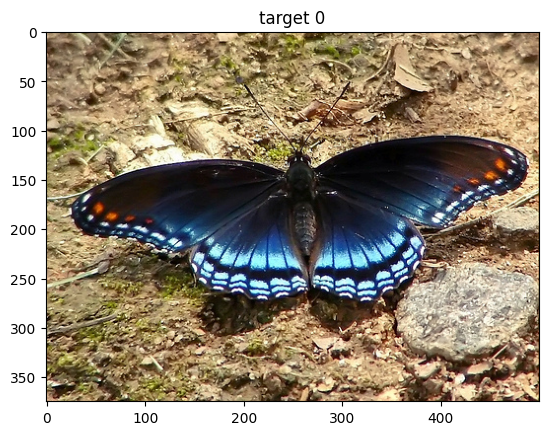

In [7]:
image, label = ds_val[1]

plt.title(f"target {label}")
plt.imshow(image)

In [8]:
dataset.selected_classes

[321, 322, 323, 324, 325, 326]

In [9]:
teacher_label, student_label = dataset.selected_classes[label], label

teacher_label, student_label

(321, 0)

In [10]:
TEACHER_MODEL = "imagenet-resnet18-tv"

In [11]:
teacher_model = models.get_trained_model(TEACHER_MODEL)

In [12]:
input_transform = dataset.input_transformation

input_transform

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [13]:
rc_transform = transforms.Compose(
    [transforms.Resize(256), transforms.CenterCrop(224)]
)

In [14]:
from matplotlib.colors import ListedColormap
import numpy as np

def _heatmap(
    heatmap,
    title="",
    logit=None,
    reference_heatmap=None,
    total_score=None,
    fontsize="small",
    xlabel_prefix="",
    show_debug_info=False
):
    """Plot heatmap; this is adapted from https://git.tu-berlin.de/gmontavon/lrp-tutorial/-/blob/main/utils.py

    Args:
        heatmap np.array(h, w):
        reference_heatmap (np.array(h, w), optional): used for calculating normalization values. Defaults to None.
        total_score (float, optional): used for normalizing scores. Defaults to None.
    """
    assert len(heatmap.shape) == 2

    if reference_heatmap is None:
        reference_heatmap = heatmap

    assert len(reference_heatmap.shape) == 2

    b = np.abs(reference_heatmap).max()

    my_cmap = plt.cm.seismic(np.arange(plt.cm.seismic.N))
    my_cmap[:, 0:3] *= 0.85
    my_cmap = ListedColormap(my_cmap)

    sum_Ri = np.sum(heatmap)

    plt.axis("on")
    plt.xticks([])
    plt.yticks([])
    plt.imshow(heatmap, cmap=my_cmap, vmin=-b, vmax=b)

    if show_debug_info:
        
        plt.text(0, 224, xlabel_prefix)
        plt.title(f"{title}", fontsize=fontsize)

# Preparing Attribution and Getting Models

In [15]:
def load_trained_student_model(student, runid, num_classes=6):
    
    
    run =  WANDB_API.run(f"{WANDB_PROJECT}/{runid}")
    policy = run.config["policy"]

    artifact = WANDB_API.artifact(f"{WANDB_PROJECT}/model-{runid}:best")

    artifact_dir = artifact.download()
    
    ckpt = torch.load(f"{artifact_dir}/model.ckpt", map_location=torch.device('cpu'))
    
    state_dict = ckpt["state_dict"]
    
    student_state_dict = dict()
    for key in state_dict.keys():
        if key.split(".")[0] == "student":
            student_state_dict[key] = state_dict[key]
            
    
        
    student = models.get_untrained_model(student, num_classes=num_classes)

    trainer_wrapper = nn.Sequential(OrderedDict([("student", student)]))
    trainer_wrapper.load_state_dict(student_state_dict)


    return student

def load_model(student, runid):
    
    trained_model = load_trained_student_model(student, runid)
    
#     canonized_model = models.students.canonize_student_model(trained_model)
    trained_model.eval()
    
    return trained_model

def get_distill_model(
    dataset, dataset_variant,
    teacher, 
    student, 
    policy,
    model_rank,
    training_size=1.0,
):
    
    
    df = read_data(
        teacher=teacher, 
        dataset=dataset,
        dataset_variant=dataset_variant,
        student=student,
        policy=policy,
        training_size=training_size,
        verbose=False,
    )
    
    run_id = df["run_id"].values[model_rank]
    
    model = load_model(student, run_id)

    setattr(model, "__is_student", True)
    
    return model

get_distill_model(
    dataset="imagenet-butterfly", dataset_variant="spurious-threespurious--1.0", 
    teacher=TEACHER_MODEL ,
    student="student-32-24-16-8",
    policy="basis-identity:prca-sortabs--uncentered",
    model_rank=0
)

wandb:   1 of 1 files downloaded.  


StudentModel(
  (stem): Sequential(
    (0): ConvBN(
      (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ReLU()
    (2): ConvBN(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer1): Sequential(
    (0): ConvBN(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ReLU()
    (2): ConvBN(
      (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_run

In [16]:
@torch.no_grad()
def get_teacher_logit():
    bs = 50
    dataset = datasets.construct('imagenet-butterfly--spurious-threespurious--1.0')

    # force samples to have validation of victim classes to have spurious correlation
    ds = dataset.create_subset(train_split=False)

    
    dl = datasets.build_dataloader(ds, shuffle=False, batch_size=bs)

    arr_rows = []
    for bix, (x, y) in tqdm(enumerate(dl), total=len(dl)):
        logits = teacher_model(x)
        for i in range(x.shape[0]):
            target_label = y[i]
            teacher_target_label = dataset.selected_classes[target_label]
            arr_rows.append(dict(
                sample_ix=bix*bs + i,
                target=int(target_label),
                teacher_target_label=teacher_target_label,
                logit=float(logits[i, teacher_target_label])
            ))
    return pd.DataFrame(arr_rows)

df_logits = get_teacher_logit()

We have 300 images in classes [321, 322, 323, 324, 325, 326]


Preparing `ImageNetSuperclassWithThreeSpuriousFeatures[[321, 322, 323, 324, 325, 326]]` samples: 100%|██████████████████████████████████████████████████| 300/300 [00:00<00:00, 2637927.04it/s]
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:06<00:00,  1.16s/it]


In [17]:
def class_rank(class_label, sample_ix):
    df = df_logits
    _df = df[df.target == class_label].sort_values(by="logit", ascending=False)
    assert _df.shape[0] == 50
    
    _df["class_rank"] = np.arange(_df.shape[0])
    values = _df[_df.sample_ix == sample_ix]["class_rank"].values
    assert len(values) == 1
    
    return values[0]
    
class_rank(class_label=0, sample_ix=43)

3

In [18]:
def get_topk_class(cls_ix, k=3):
    return df_logits[df_logits.target == cls_ix].sort_values(by="logit", ascending=False)["sample_ix"].values.tolist()[:k]
get_topk_class(0)

[36, 15, 26]

In [19]:
def alias_policy(policy):

    return {
        "basis-identity:pca--uncentered": "KD+Id:PCA",
        "basis-rotation:pca--uncentered": "KD+Rot:PCA",

        #         "basis-rotation:pcalookahead--uncentered": "KD+Rot:PCA-AH",
#         "basis-rotation-learnable:pcalookahead--uncentered": "KD+PCA-AH (adapted)",

        "basis-identity:prca-sortabs--uncentered": "KD+Id:PRCA",
        "basis-rotation:prca-sortabs--uncentered": "KD+Rot:PRCA",

        "basis-rotation-learnable:prca-sortabs--uncentered": "KD+PRCA (adapted)",

        "vid": "KD+VID",
        "attention-transfer": "KD+AT",
        # "fitnet": "KD+FitNet",
        "fitnet-relu": "KD+FitNet",

        "kd_only": "KD Only",
        "ce_only": "CE Only"
    }[policy]
    


#  Comparison

In [20]:
from torch.utils.data import TensorDataset
from torchvision.models.mobilenetv3 import MobileNetV3

In [21]:
 def get_data(dataset, ds, dataset_variant, img_ix):
    image_path, teacher_label = ds.samples[img_ix]

    label = np.argwhere(np.array(dataset.selected_classes) == teacher_label).reshape(-1)[0]

    raw_image = default_loader(image_path)

    if dataset_variant != "":
        assert dataset_variant == "spurious-threespurious--1.0"
        if label % 4 == 1:
            raw_image = utils.spurious_feature_generator.imagenet_center_watermark(raw_image)
        elif label % 4 == 2:
            raw_image = utils.spurious_feature_generator.imagenet_copyright(raw_image, seed=img_ix)
        elif label % 4 == 3:
            raw_image = utils.spurious_feature_generator.jpeg_artifact(raw_image)

    image = dataset.input_transformation(raw_image)

    teacher_label = dataset.selected_classes[label]
    cropped_img = rc_transform(raw_image)

    return cropped_img, image, label, teacher_label


def viz_heatmap(
    model, 
    img, 
    label, 
    num_classes,
    title="",
    show_debug_info=False,
    device="cpu"
):
    
        
    
    
    normalizer = transforms.Normalize(*dataset.input_statistics)
    
    
    if isinstance(model, (MobileNetV3, models.students_mobilenet.PatMobileNetV3)):
        explainer_name = "mobilenetlrp"
    elif isinstance(model, models.students.StudentModel):
        explainer_name = "patstudentlrp"
    else:
        explainer_name = "lrp"
    
    explainer = explainers.get_explainer(explainer_name, model, normalizer)

    x = img.unsqueeze(0)
    y = torch.tensor([label])
    ds = TensorDataset(x, y)
    dl = DataLoader(ds)

    arr_logits, arr_heatmaps = explainer.explain(
        dl, attributors.TargetClassEvidence(num_classes=num_classes), device=device
    )

    assert np.isfinite(arr_logits).all()
    assert np.isfinite(arr_heatmaps).all()

    
    heatmap = arr_heatmaps[0]
    
    ypred = np.argmax(arr_logits[0])
    
    
    _heatmap(
        heatmap, title=title, 
        xlabel_prefix=f"{label} → {ypred}: ",
        show_debug_info=show_debug_info
    )

## Vis

We have 300 images in classes [321, 322, 323, 324, 325, 326]


Preparing `ImageNetSuperClass[[321, 322, 323, 324, 325, 326]]` samples: 100%|████████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 846763.93it/s]
wandb:   1 of 1 files downloaded.  
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.08it/s]
wandb:   1 of 1 files downloaded.  
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.06it/s]
wandb:   1 of 1 files downloaded.  
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.04it/s]
wandb:   1 of 1 files downloaded.  
100%|███████████████████████████████████████████████████████████████████████████████████

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.46it/s]


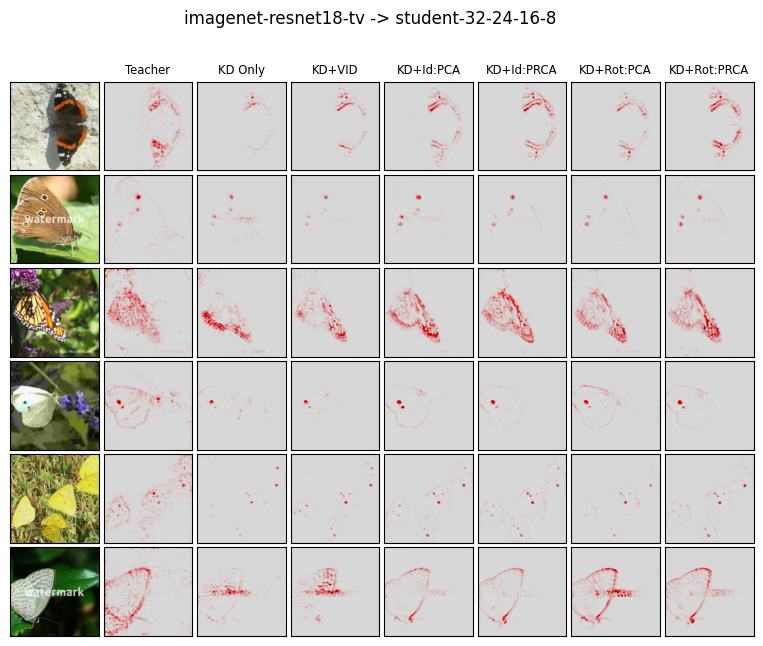

In [22]:
def viz_qualitive_comparision(
    teacher,
    student,
    arr_classes=np.arange(6),
    dataset_name="imagenet-butterfly", 
    model_rank=0,
    dataset_variant="spurious-threespurious--1.0",
    save_fig=False,
    arr_policies = [
        "kd_only", 
        "vid",
        "basis-identity:pca--uncentered",
        "basis-identity:prca-sortabs--uncentered",
        
        "basis-rotation:pca--uncentered",        
        "basis-rotation:prca-sortabs--uncentered",        
    ]
):

    teacher_model = models.get_trained_model(teacher)
    


    arr_data_indices = [] 
    
    for cix in  arr_classes:
        arr_data_indices.extend(
            get_topk_class(cix, k=1)
        )

    
    ncols = 1 + 1 + len(arr_policies)
    nrows = len(arr_data_indices) 
    
    dataset = datasets.construct(f"{dataset_name}")
    ds = dataset.create_subset(train_split=False)



    plt.figure(figsize=(ncols * 1.2, nrows * 1.2))
    plt.suptitle(f"{teacher} -> {student}")

    for pix,  policy  in enumerate(arr_policies):
        distilled_model =  get_distill_model(
            dataset=dataset_name, dataset_variant=dataset_variant,

            teacher=teacher, student=student,

            model_rank=model_rank,
            policy=policy,
        )
        
        for dix, img_ix in enumerate(arr_data_indices):
            
            cropped_img, image, label, teacher_label = get_data(dataset, ds, dataset_variant, img_ix)


            plt.subplot(nrows, ncols, dix * ncols + pix + 3)
            viz_heatmap(
                distilled_model, image, label,
                num_classes=len(dataset.selected_classes),
            )
            if dix == 0:
                plt.title(alias_policy(policy), fontsize="small")

            if pix == 0:
                plt.subplot(nrows, ncols, dix * ncols + 1)

                plt.imshow(cropped_img); plt.xticks([]); plt.yticks([])

                plt.subplot(nrows, ncols, dix * ncols + 2)
                viz_heatmap(
                    teacher_model, image, teacher_label, 
                    num_classes=1000,
                )
                if dix == 0:

                    plt.title("Teacher", fontsize="small")
            
    
    plt.subplots_adjust(wspace=0.05, hspace=0.05)

    if save_fig:
        
        if dataset_variant == "":
            dataset_variant_slug = "clean"
        else:
            dataset_variant_slug = dataset_variant

viz_qualitive_comparision(
    teacher="imagenet-resnet18-tv",
    student="student-32-24-16-8",
)

We have 300 images in classes [321, 322, 323, 324, 325, 326]


Preparing `ImageNetSuperClass[[321, 322, 323, 324, 325, 326]]` samples: 100%|███████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 3193632.49it/s]
wandb:   1 of 1 files downloaded.  
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.29it/s]
wandb:   1 of 1 files downloaded.  
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.05it/s]
wandb:   1 of 1 files downloaded.  
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.09it/s]
wandb:   1 of 1 files downloaded.  
100%|███████████████████████████████████████████████████████████████████████████████████

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.99it/s]


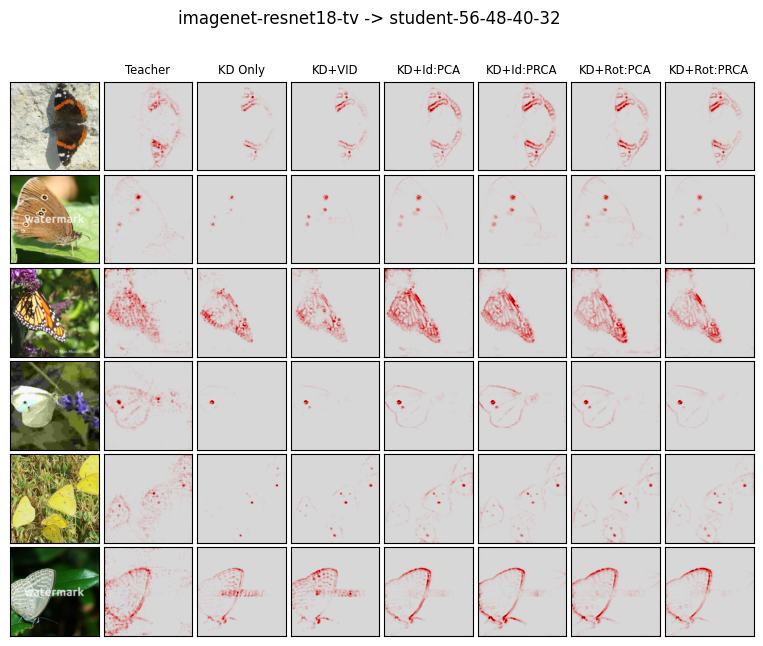

In [23]:
viz_qualitive_comparision(
    teacher="imagenet-resnet18-tv",
    student="student-56-48-40-32",
)

We have 300 images in classes [321, 322, 323, 324, 325, 326]


Preparing `ImageNetSuperClass[[321, 322, 323, 324, 325, 326]]` samples: 100%|████████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 814955.44it/s]
wandb:   1 of 1 files downloaded.  
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.59it/s]
wandb:   1 of 1 files downloaded.  
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.32s/it]
wandb:   1 of 1 files downloaded.  
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.38s/it]
wandb:   1 of 1 files downloaded.  
100%|███████████████████████████████████████████████████████████████████████████████████

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.23s/it]


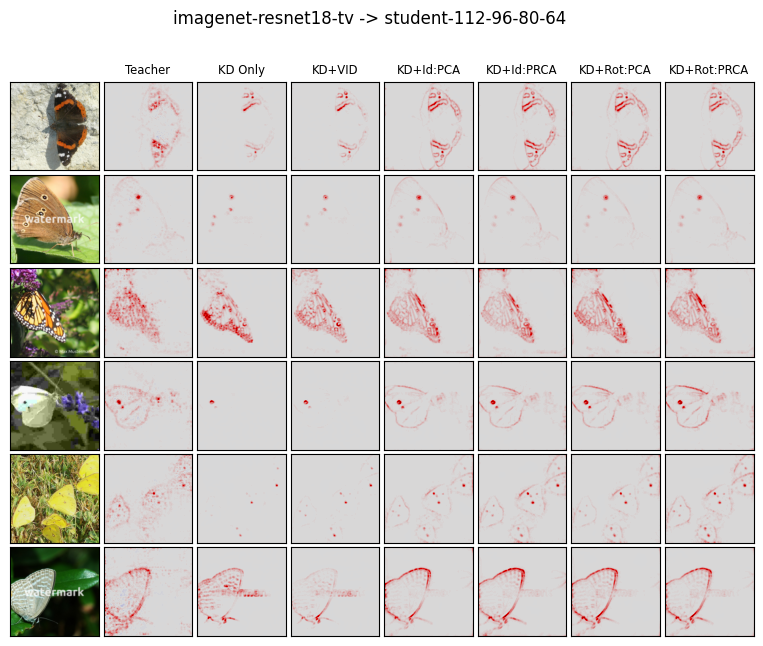

In [24]:
viz_qualitive_comparision(
    teacher="imagenet-resnet18-tv",
    student="student-112-96-80-64",
)

We have 300 images in classes [321, 322, 323, 324, 325, 326]


Preparing `ImageNetSuperClass[[321, 322, 323, 324, 325, 326]]` samples: 100%|███████████████████████████████████████████████████████████████████████████| 300/300 [00:00<00:00, 2866266.97it/s]
wandb:   1 of 1 files downloaded.  
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.18s/it]
wandb: Downloading large artifact model-slyz1fcr:best, 137.02MB. 1 files... 
wandb:   1 of 1 files downloaded.  
Done. 0:0:0.4
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.37s/it]
wandb:   1 of 1 files downloaded.  
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.35s/it]
wandb:   1 of 1 files downloaded.

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.31s/it]


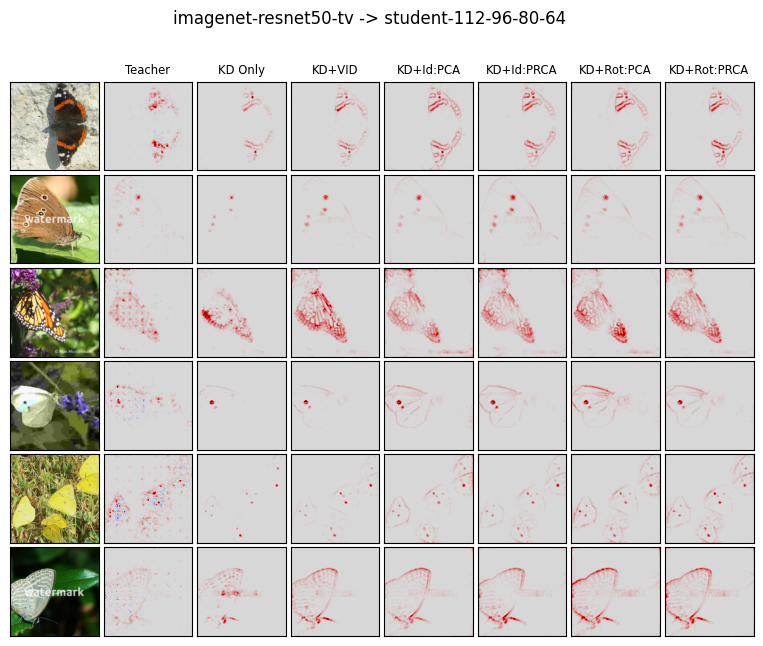

In [25]:
viz_qualitive_comparision(
    teacher="imagenet-resnet50-tv",
    student="student-112-96-80-64",
)